# Volume change on shelf over time, ACCESS-OM2-01

This notebook is incomplete, because I haven't run the daily data for ACCESS-OM2-01 yet.

In [1]:
import glob
import dask.distributed as dsk
import matplotlib.pyplot as plt
import xarray as xr
import cf_xarray as cfxr
import numpy as np
import xesmf as xe
from matplotlib.colors import to_rgba

import cmocean as cm
import cartopy.crs as ccrs

import cartopy.feature as cft
import matplotlib.path as mpath

import warnings # ignore these warnings
warnings.filterwarnings("ignore", category = FutureWarning)
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = RuntimeWarning)

In [2]:
lat_slice = slice(-79,-59)

# Importing data
paths_C = np.sort(glob.glob('/scratch/x77/kc5856/access-om2/archive/01deg_jra55v13_ryf9091_21mbath_daily-fc7aefa1/output000/ocean/ocean_daily.nc'))
paths_M = np.sort(glob.glob('/scratch/x77/kc5856/access-om2/archive/access-ssp126-sofia_daily-expt-3deaf0e1/output000/ocean/ocean_daily.nc'))

In [3]:
paths_M

array(['/scratch/x77/kc5856/access-om2/archive/access-ssp126-sofia_daily-expt-3deaf0e1/output000/ocean/ocean_daily.nc'],
      dtype='<U109')

In [4]:
# Time variant variables
def preprocess(ds):
    ds = ds[['dzt','salt_tendency']].sel(yt_ocean=lat_slice)
    return ds

data_C = xr.open_mfdataset(paths_C, preprocess = preprocess, chunks = 'auto')
data_M = xr.open_mfdataset(paths_M, preprocess = preprocess, chunks = 'auto')

In [5]:
# Shelf mask

def shelf_mask_isobath(var, model_dict):

    paths = {
             "mom5": "/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz",
             "mom6_01": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_01deg.nc",
            "mom6_005": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_005deg.nc"
             }

    var = var.cf.sel({'latitude': slice(-90, -59)})

    if paths[model_dict][-3:] == '.nc':
        shelf_mask = xr.open_dataset(paths[model_dict])['contour_masked_above']
    else:
        contour_file = np.load(paths[model_dict])
        shelf_mask = xr.DataArray(contour_file['contour_masked_above'],
                                  coords = var.coords, 
                                  dims = var.dims,
                                  name = 'contour_masked_above')
    
    shelf_mask = xr.where(shelf_mask == 0, 1, 0)
    masked_var = var * shelf_mask
    
    return masked_var, shelf_mask

In [6]:
depth = xr.open_dataset('/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath/output012/ocean/ocean_grid.nc')['ht']
land_mask = (0 * depth).fillna(1)
land = xr.where(np.isnan(depth.rename('land_1')), 1, np.nan)
depth_shelf, shelf_mask = shelf_mask_isobath(depth, 'mom5')

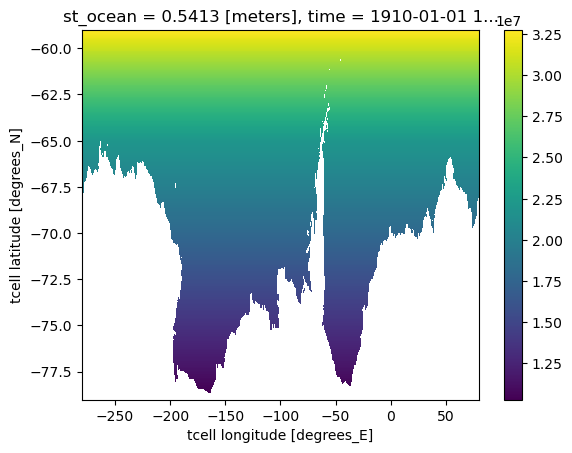

In [7]:
# Doing spatial average
area = xr.open_dataset('/scratch/x77/kc5856/access-om2/archive/01deg_jra55v13_ryf9091_21mbath_daily-fc7aefa1/output000/ocean/ocean_grid.nc')['area_t']
var = data_C.salt_tendency.isel(time=0).isel(st_ocean=0)
area_corr = area*(var*0 +1)
area_corr.plot()

In [8]:
# Salinity variable
vol_C = (area_corr * data_C.dzt).where(shelf_mask == 1)
vol_M = (area_corr * data_M.dzt).where(shelf_mask == 1)

In [9]:
# Spatial average
shelf_area = area_corr.where(shelf_mask == 1).sum(['xt_ocean', 'yt_ocean'])

vol_C_time = (area_corr * vol_C).sum(['xt_ocean', 'yt_ocean']) / shelf_area
vol_M_time = (area_corr * vol_M).sum(['xt_ocean', 'yt_ocean']) / shelf_area

In [10]:
vol_C_time

<xarray.DataArray (time: 3, st_ocean: 75)> Size: 900B
dask.array<truediv, shape=(3, 75), dtype=float32, chunksize=(2, 38), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) object 24B 1910-01-01 12:00:00 ... 1910-01-03 12:00:00
  * st_ocean  (st_ocean) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03

In [11]:
vol_C_time = vol_C_time.load()
vol_M_time = vol_M_time.load()

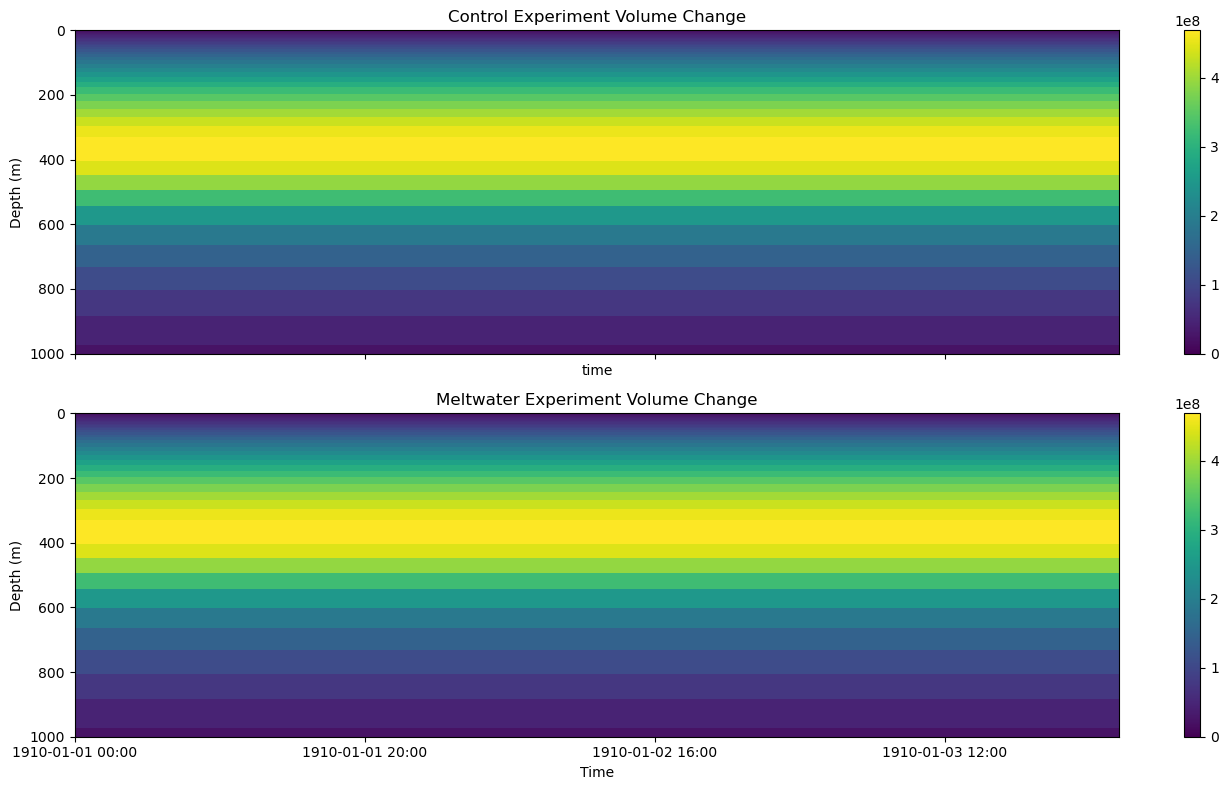

In [12]:
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Control experiment
vol_C_time.plot(ax=axs[0], y='st_ocean', cmap='viridis')
axs[0].set_ylabel('Depth (m)')
axs[0].set_ylim(0,1000)
axs[0].invert_yaxis()
axs[0].set_title('Control Experiment Volume Change')

# Meltwater experiment
vol_M_time.plot(ax=axs[1], y='st_ocean', cmap='viridis')
axs[1].set_ylabel('Depth (m)')
axs[1].set_ylim(0,1000)
axs[1].invert_yaxis()
axs[1].set_title('Meltwater Experiment Volume Change')

axs[1].set_xlabel('Time')

plt.tight_layout()
plt.show()

In [13]:
# Anomaly
vol_anom_time = vol_M_time - vol_C_time
vol_anom_time = vol_anom_time.load()

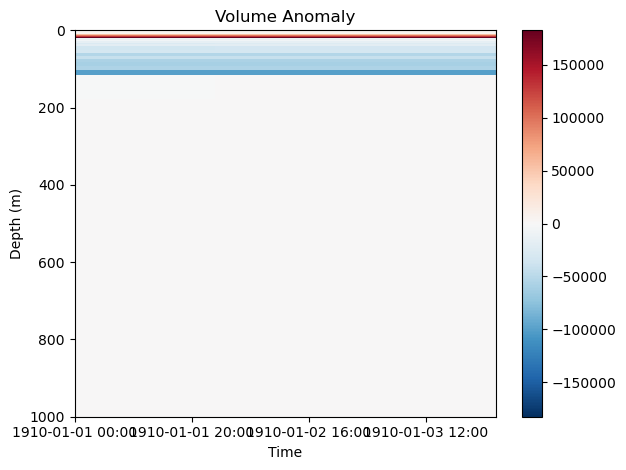

In [14]:
vol_anom_time.plot(y='st_ocean', cmap='RdBu_r')
plt.ylabel('Depth (m)')
plt.ylim(0,1000)
plt.title('Volume Anomaly')
plt.gca().invert_yaxis()
plt.xlabel('Time')
plt.tight_layout()
plt.show()

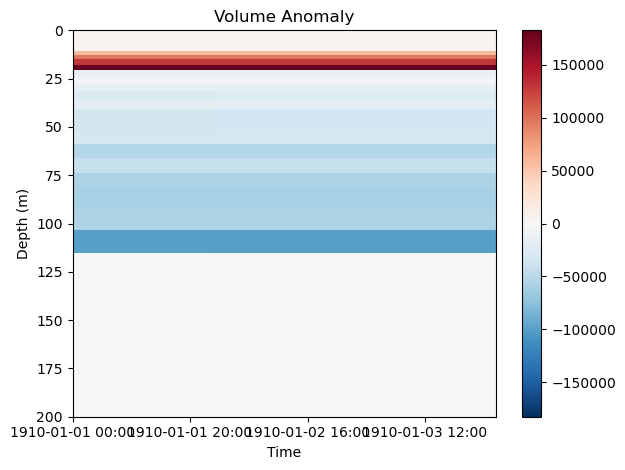

In [15]:
vol_anom_time.plot(y='st_ocean', cmap='RdBu_r')
plt.ylabel('Depth (m)')
plt.ylim(0,200)
plt.title('Volume Anomaly')
plt.gca().invert_yaxis()
plt.xlabel('Time')
plt.tight_layout()
plt.show()

In [16]:
vol_anom_time

<xarray.DataArray (time: 3, st_ocean: 75)> Size: 900B
array([[ 3.422000e+03,  3.782000e+03,  4.182000e+03,  4.622000e+03,
         5.108000e+03,  5.644000e+03,  6.236000e+03,  5.626000e+04,
         9.760400e+04,  1.306880e+05,  1.821600e+05, -1.208800e+04,
        -7.008000e+03, -1.707200e+04, -2.577600e+04, -1.915200e+04,
        -3.424800e+04, -3.432000e+04, -3.223200e+04, -5.415200e+04,
        -4.248000e+04, -5.792000e+04, -6.054400e+04, -5.696000e+04,
        -1.002240e+05, -3.200000e+01, -3.200000e+01, -3.200000e+01,
        -3.200000e+01,  0.000000e+00,  3.200000e+01,  6.400000e+01,
         9.600000e+01,  1.280000e+02,  1.920000e+02,  1.920000e+02,
         1.600000e+02,  1.920000e+02,  1.600000e+02,  1.600000e+02,
         1.440000e+02,  9.600000e+01,  8.000000e+01,  4.800000e+01,
         3.200000e+01,  8.000000e+00,  2.000000e+00,  3.000000e+00,
         3.000000e+00,  1.000000e+00,  0.000000e+00,  1.000000e+00,
         0.000000e+00,  2.500000e-01,  2.500000e-01,  0.000000e+00,
         1.171875e-02,  0.000000e+00,  0.000000e+00,  0.000000e+00,
         0.000000e+00,  0.000000e+00,  0.000000e+00,  0.000000e+00,
         0.000000e+00,  0.000000e+00,  0.000000e+00,  0.000000e+00,
         0.000000e+00,  0.000000e+00,  0.000000e+00,  0.000000e+00,
         0.000000e+00,  0.000000e+00,  0.000000e+00],
       [ 3.434000e+03,  3.798000e+03,  4.196000e+03,  4.636000e+03,
...
         0.000000e+00,  0.000000e+00,  0.000000e+00],
       [ 3.438000e+03,  3.798000e+03,  4.196000e+03,  4.642000e+03,
         5.130000e+03,  5.662000e+03,  6.260000e+03,  5.641600e+04,
         9.783600e+04,  1.309600e+05,  1.824920e+05, -1.192000e+04,
        -6.832000e+03, -1.688800e+04, -2.559200e+04, -1.896800e+04,
        -3.404800e+04, -3.412000e+04, -3.203200e+04, -5.393600e+04,
        -4.227200e+04, -5.771200e+04, -6.032000e+04, -5.672000e+04,
        -1.000000e+05,  1.920000e+02,  2.560000e+02,  2.400000e+02,
         2.880000e+02,  3.520000e+02,  3.840000e+02,  5.120000e+02,
         5.760000e+02,  6.720000e+02,  7.360000e+02,  7.040000e+02,
         6.720000e+02,  6.080000e+02,  5.760000e+02,  3.840000e+02,
         3.360000e+02,  2.080000e+02,  1.760000e+02,  1.200000e+02,
         7.200000e+01,  4.000000e+01,  1.800000e+01,  1.200000e+01,
         6.000000e+00,  5.000000e+00,  3.500000e+00,  3.000000e+00,
         2.750000e+00,  1.250000e+00,  7.500000e-01,  1.562500e-01,
         1.171875e-02,  0.000000e+00,  0.000000e+00,  0.000000e+00,
         0.000000e+00,  0.000000e+00,  0.000000e+00,  0.000000e+00,
         0.000000e+00,  0.000000e+00,  0.000000e+00,  0.000000e+00,
         0.000000e+00,  0.000000e+00,  0.000000e+00,  0.000000e+00,
         0.000000e+00,  0.000000e+00,  0.000000e+00]], dtype=float32)
Coordinates:
  * time      (time) object 24B 1910-01-01 12:00:00 ... 1910-01-03 12:00:00
  * st_ocean  (st_ocean) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03

Okay so we see that volume is changing, mostly around 300m depth. Is there a better way to present this information? This plot is a bit rough.

In [17]:
vol_C_column = vol_C_time.sum('st_ocean')
vol_M_column = vol_M_time.sum('st_ocean')

I don't think I need to thickness-weight this because volcello should already account for that?

In [18]:
vol_C_column = vol_C_column.load()
vol_M_column = vol_M_column.load()

In [19]:
vol_anom_column = vol_M_column - vol_C_column

In [21]:
vol_M_column

<xarray.DataArray (time: 3)> Size: 12B
array([8.319953e+09, 8.320048e+09, 8.320109e+09], dtype=float32)
Coordinates:
  * time     (time) object 24B 1910-01-01 12:00:00 ... 1910-01-03 12:00:00

In [22]:
vol_C_column

<xarray.DataArray (time: 3)> Size: 12B
array([8.3200061e+09, 8.3200911e+09, 8.3201516e+09], dtype=float32)
Coordinates:
  * time     (time) object 24B 1910-01-01 12:00:00 ... 1910-01-03 12:00:00

In [20]:
vol_anom_column

<xarray.DataArray (time: 3)> Size: 12B
array([-53248., -43008., -42496.], dtype=float32)
Coordinates:
  * time     (time) object 24B 1910-01-01 12:00:00 ... 1910-01-03 12:00:00

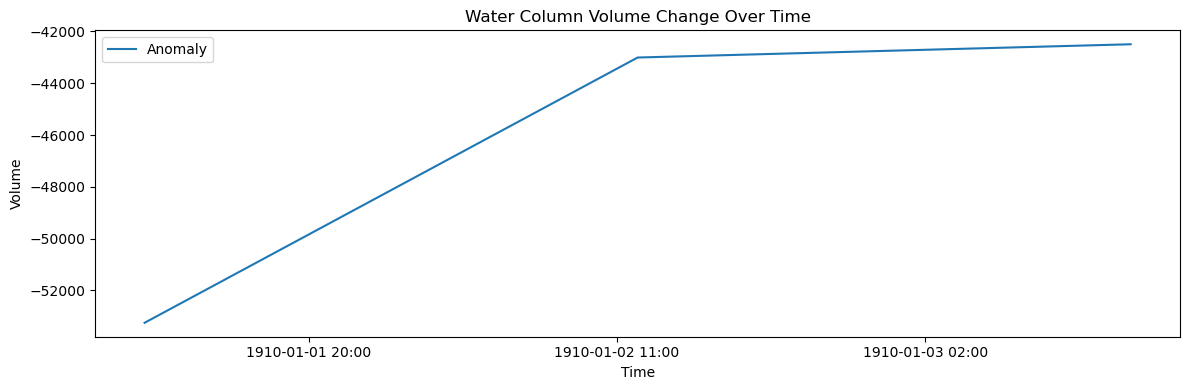

In [19]:
plt.figure(figsize=(12, 4))

# vol_C_column.plot(label='Control')
# vol_M_column.plot(label='Meltwater')
vol_anom_column.plot(label='Anomaly')

plt.legend()
plt.ylabel('Volume')
plt.xlabel('Time')
plt.title('Water Column Volume Change Over Time')
plt.tight_layout()
plt.show()

In [20]:
vol_anom_column_pan = xr.open_dataarray('/g/data/x77/kc5856/analysis/access-panan-comparison/vol_anom_column_pan01.nc')

In [25]:
vol_anom_column_acc_new = vol_anom_column.to_series()
vol_anom_column_acc_new = vol_anom_column_new['1910-01-01':'1919-12-16']
vol_anom_column_pan_new = vol_anom_column_pan.to_series()
vol_anom_column_pan_new = vol_anom_column_pan_new['2001-01-01':'2010-10-16']

In [26]:
# Reset index to normalized months
vol_anom_column_pan_new.index = range(1, len(vol_anom_column_pan_new)+1)
vol_anom_column_acc_new.index = range(1, len(vol_anom_column_acc_new)+1)

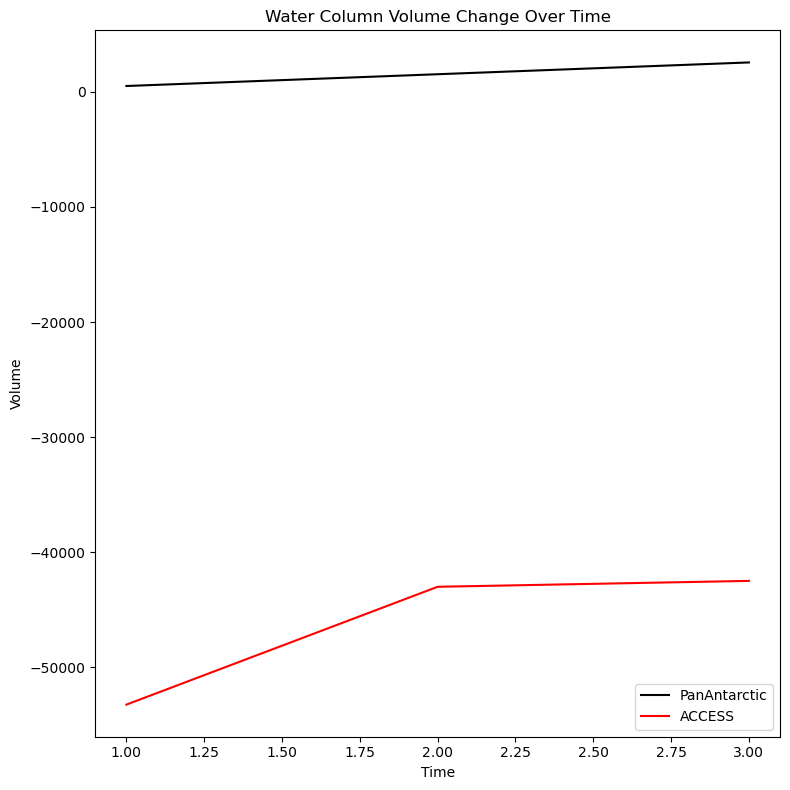

In [30]:
plt.figure(figsize=(8, 8))

plt.plot(vol_anom_column_pan_new.index, vol_anom_column_pan_new.values, label="PanAntarctic", color='black')
plt.plot(vol_anom_column_acc_new.index, vol_anom_column_acc_new.values, label="ACCESS", color='red')

plt.legend()
plt.ylabel('Volume')
plt.xlabel('Time')
plt.title('Water Column Volume Change Over Time')
plt.tight_layout()
plt.show()